In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("C:/Users/USUARIO/Desktop/etl_2026_01/Workshop/data/raw/candidates.csv", sep=';')

In [6]:
df.head()

,First Name,Last Name,Email,Application Date,Country,YOE,Seniority,Technology,Code Challenge Score,Technical Interview Score
0,Bernadette,Langworth,leonard91@yahoo.com,2021-02-26,Norway,2,Intern,Data Engineer,3,3
1,Camryn,Reynolds,zelda56@hotmail.com,2021-09-09,Panama,10,Intern,Data Engineer,2,10
2,Larue,Spinka,okey_schultz41@gmail.com,2020-04-14,Belarus,4,Mid-Level,Client Success,10,9
3,Arch,Spinka,elvera_kulas@yahoo.com,2020-10-01,Eritrea,25,Trainee,QA Manual,7,1
4,Larue,Altenwerth,minnie.gislason@gmail.com,2020-05-20,Myanmar,13,Mid-Level,Social Media Community Management,9,7


## 1. Data Quality

In [ ]:
#first of all, let's see the quality of the data

In [7]:
# 1. Count null values 
print("--- Null Values ---")
print(df.isnull().sum())

# 2. Search email duplicates
duplicates = df.duplicated(subset=['Email']).sum()
print(f"\nEmail duplicates founded: {duplicates}")

# Seeing which emails are duplicated:
df[df.duplicated(subset=['Email'], keep=False)].sort_values('Email')

--- Null Values ---
First Name                   0
Last Name                    0
Email                        0
Application Date             0
Country                      0
YOE                          0
Seniority                    0
Technology                   0
Code Challenge Score         0
Technical Interview Score    0
dtype: int64

Email duplicates founded: 167


,First Name,Last Name,Email,Application Date,Country,YOE,Seniority,Technology,Code Challenge Score,Technical Interview Score
15823,Herta,Bartoletti,abbigail94@yahoo.com,2022-02-20,Dominican Republic,21,Mid-Level,Client Success,5,8
31764,Gavin,Brakus,abbigail94@yahoo.com,2019-07-27,Croatia,4,Junior,DevOps,6,2
21805,Jayce,Blick,addison_bode@hotmail.com,2019-08-27,Luxembourg,4,Lead,Development - Backend,7,2
32069,Malika,Krajcik,addison_bode@hotmail.com,2019-02-02,Lithuania,24,Architect,Database Administration,10,3
41691,Lorine,Howe,alberta95@gmail.com,2019-05-28,Afghanistan,21,Junior,Adobe Experience Manager,7,2
...,...,...,...,...,...,...,...,...,...,...
14135,Malcolm,Mante,wilhelm76@hotmail.com,2018-11-30,Czech Republic,9,Lead,Security Compliance,3,4
43614,Katlynn,Brown,winston14@hotmail.com,2020-02-14,Morocco,17,Senior,Mulesoft,0,8
13653,Clarissa,Rogahn,winston14@hotmail.com,2022-07-04,Brunei Darussalam,25,Architect,QA Manual,7,0
34827,Edgardo,Kohler,zachery86@yahoo.com,2022-06-13,Madagascar,24,Junior,Data Engineer,0,0


we see that the data doesnt have any null values but have some anomalies and email duplicates 

## 2. Sanity Checks

In [ ]:
print("--- Statistical Summary of Metrics ---")
print(df[['YOE', 'Code Challenge Score', 'Technical Interview Score']].describe())

--- Resumen Estadístico de Métricas ---
                YOE  Code Challenge Score  Technical Interview Score
count  50000.000000          50000.000000               50000.000000
mean      15.286980              4.996400                   5.003880
std        8.830652              3.166896                   3.165082
min        0.000000              0.000000                   0.000000
25%        8.000000              2.000000                   2.000000
50%       15.000000              5.000000                   5.000000
75%       23.000000              8.000000                   8.000000
max       30.000000             10.000000                  10.000000


In [ ]:
# Define logical business rules to detect anomalies in Seniority vs. YOE
anomalias_intern = df[(df['Seniority'] == 'Intern') & (df['YOE'] > 2)]
anomalias_trainee = df[(df['Seniority'] == 'Trainee') & (df['YOE'] > 3)]
anomalias_junior = df[(df['Seniority'] == 'Junior') & (df['YOE'] > 5)]
anomalias_lead = df[(df['Seniority'].isin(['Lead', 'Architect'])) & (df['YOE'] < 3)]

# Concatenate all detected anomalies into a single DataFrame
df_anomalias = pd.concat([anomalias_intern, anomalias_trainee, anomalias_junior, anomalias_lead])

print(f"Found {len(df_anomalias)} records with inconsistencies between Seniority and YOE.")
# print(df_anomalias[['First Name', 'Seniority', 'YOE']]) # Uncomment to view the list

Se encontraron 19949 registros con inconsistencias entre Seniority y YOE.


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_22384\538657294.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Seniority', y='YOE', data=df, palette='viridis')


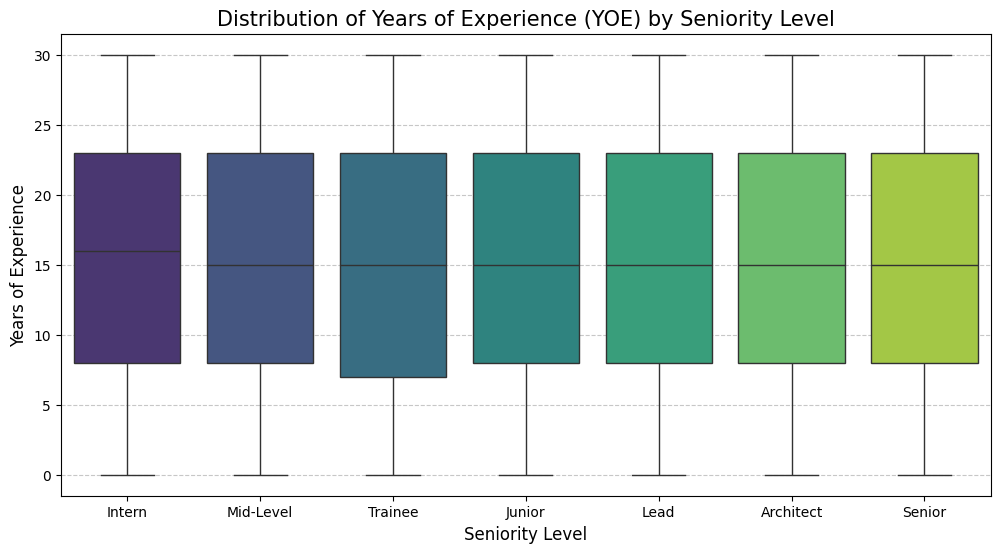

In [19]:
#Generates a boxplot to visualize the relationship between Seniority and YOE.
#This helps identify outliers and justifies the data cleaning strategy.

plt.figure(figsize=(12, 6))

# Create the boxplot
sns.boxplot(x='Seniority', y='YOE', data=df, palette='viridis')

# Add title and labels
plt.title('Distribution of Years of Experience (YOE) by Seniority Level', fontsize=15)
plt.xlabel('Seniority Level', fontsize=12)
plt.ylabel('Years of Experience', fontsize=12)

# Add a horizontal grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()